1. Import Libraries

In [5]:
import pandas as pd
import numpy as np

2. Load Dataset

In [6]:
df = pd.read_csv(r"C:\Users\GIGABYTE\Downloads\archive\Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


3. Basic Data Understanding

In [7]:
df.shape          # Rows & Columns
df.info()         # Data types
df.describe()     # Summary stats

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


4. Check Missing Values

In [8]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
df.dropna(inplace=True)   # simple approach

5.Check Duplicate Rows

In [10]:
df.duplicated().sum()

np.int64(0)

6. Convert Date Columns

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

7. Create New Useful Columns

i) Delivery Time

In [12]:
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

ii) Profit Margin

In [13]:
df['Profit Margin'] = df['Profit'] / df['Sales']

iii) Extract Time Features

In [14]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month

8. Clean Column Names

In [15]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

9. Check Outliers

In [16]:
df.describe()

,Row_ID,Order_Date,Ship_Date,Postal_Code,Sales,Quantity,Discount,Profit,Delivery_Days,Profit_Margin,Order_Year,Order_Month
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,3.958175,0.120314,2015.722233,7.809686
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000,-2.750000,2014.000000,1.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,3.000000,0.075000,2015.000000,5.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,4.000000,0.270000,2016.000000,9.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,5.000000,0.362500,2017.000000,11.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,7.000000,0.500000,2017.000000,12.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.747567,0.466754,1.123555,3.284654


Final Clean Dataset

In [17]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row_ID         9994 non-null   int64         
 1   Order_ID       9994 non-null   object        
 2   Order_Date     9994 non-null   datetime64[ns]
 3   Ship_Date      9994 non-null   datetime64[ns]
 4   Ship_Mode      9994 non-null   object        
 5   Customer_ID    9994 non-null   object        
 6   Customer_Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal_Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product_ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

STEP2: EDA

1. Import Visualization Libraries

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

2. Sales & Profit Trend Over Time

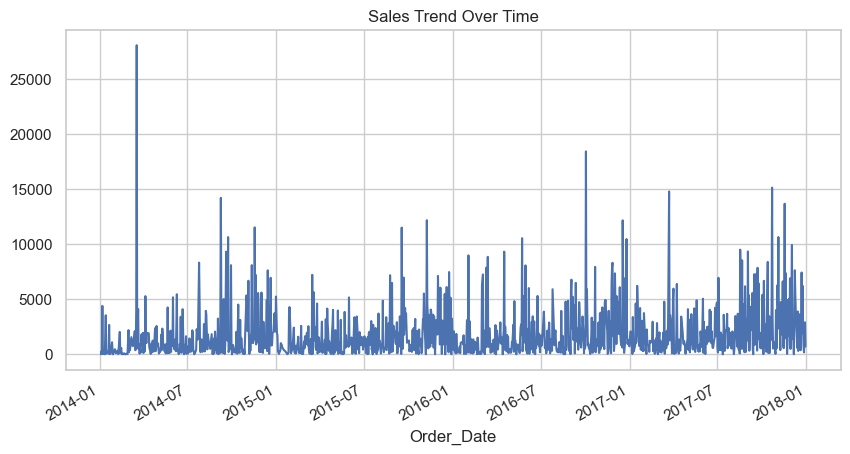

In [19]:
monthly_sales = df.groupby('Order_Date')['Sales'].sum()
plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Sales Trend Over Time")
plt.show()

INSIGHT OF THE GRAPH:
            Sales show fluctuations over time indicating seasonal demand patterns.

3. Profit by Category

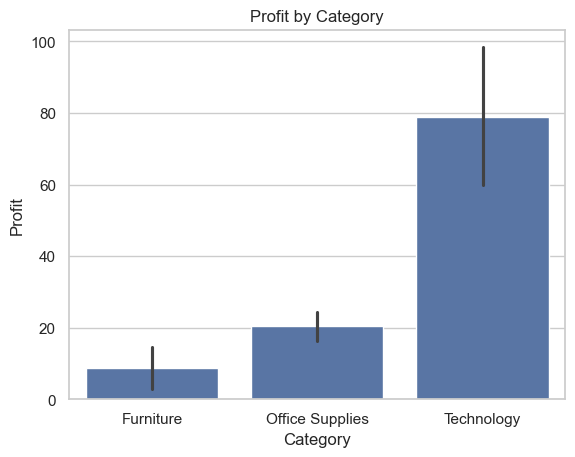

In [20]:
sns.barplot(x='Category', y='Profit', data=df)
plt.title("Profit by Category")
plt.show()

INSIGHT OF THE GRAPH:
           Identify Technology category is most profitable.

4. Sales by Sub-Category

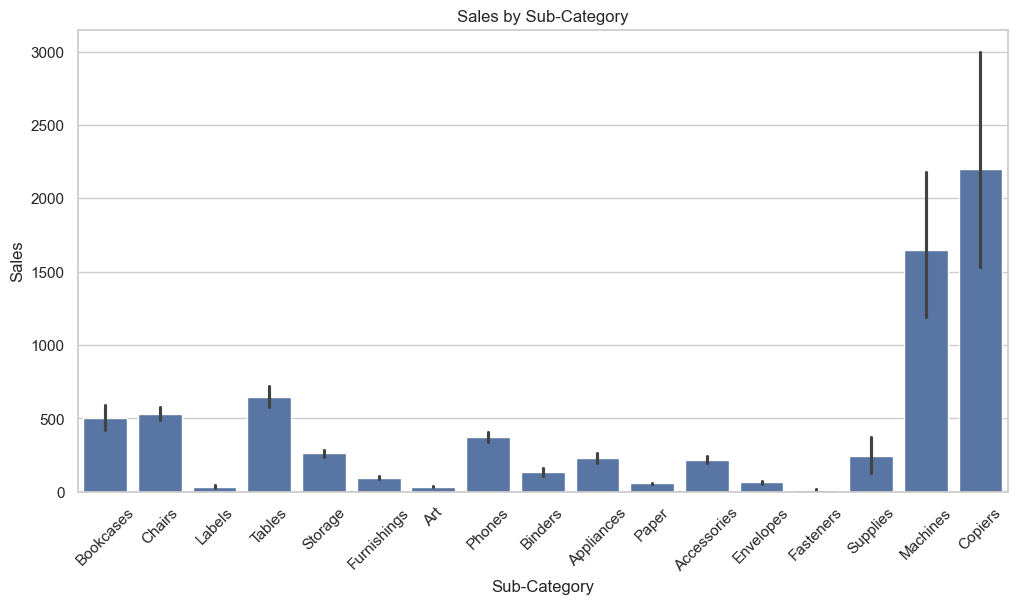

In [21]:
plt.figure(figsize=(12,6))
sns.barplot(x='Sub-Category', y='Sales', data=df)
plt.xticks(rotation=45)
plt.title("Sales by Sub-Category")
plt.show()

INSIGHT OF THE GRAPH:
           Some sub-categories generate high sales but may not be profitable.

5. Region-wise Profit

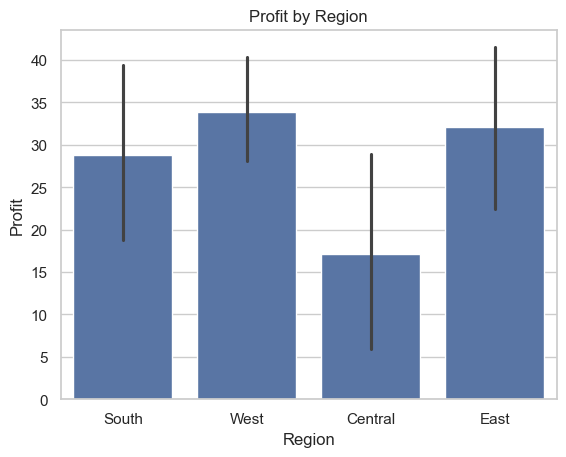

In [22]:
sns.barplot(x='Region', y='Profit', data=df)
plt.title("Profit by Region")
plt.show()

INSIGHT OF THE GRAPH:
            Detect which region is underperforming.

6. Discount vs Profit

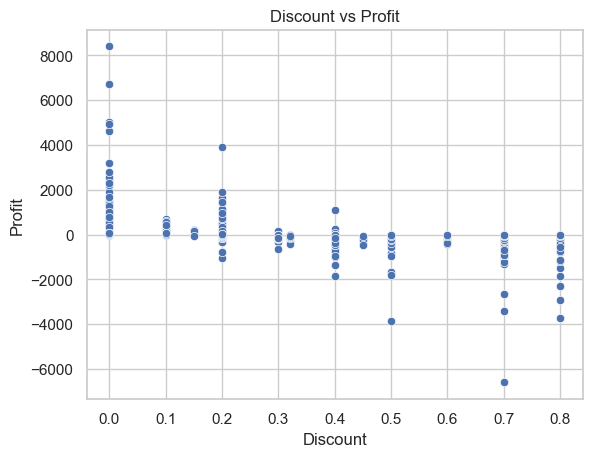

In [23]:
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()

INSIGHT OF THE GRAPH:
Higher discounts often lead to losses.

7. Segment-wise Sales

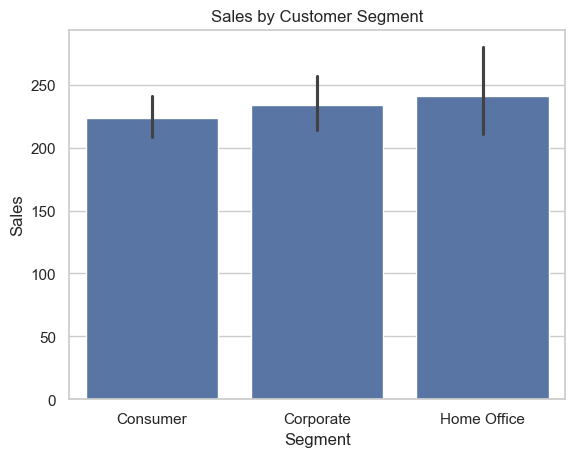

In [24]:
sns.barplot(x='Segment', y='Sales', data=df)
plt.title("Sales by Customer Segment")
plt.show()

INSIGHT OF THE GRAPH:
           Identify which customer segment contributes most revenue.

8. Top 10 Products by Sales

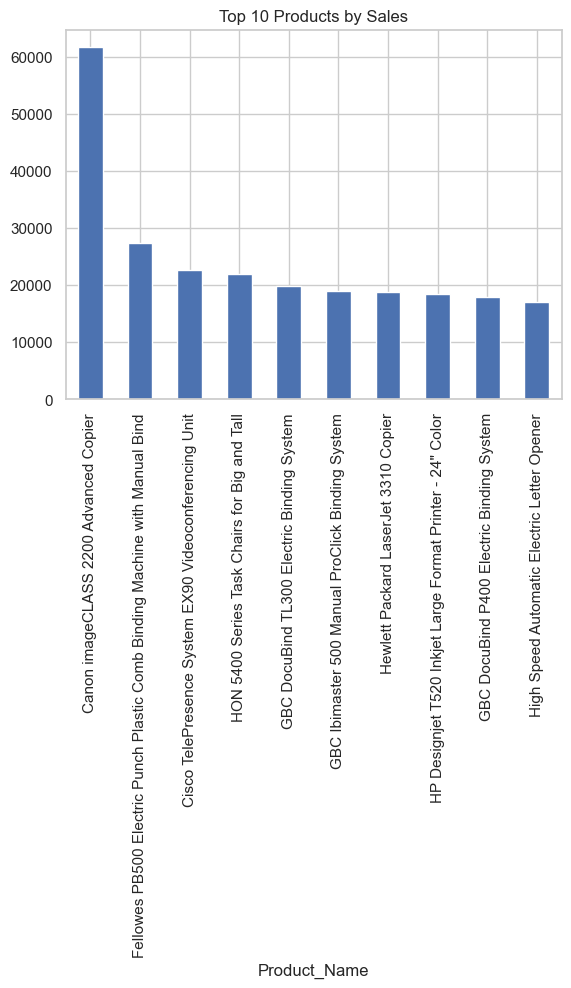

In [25]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.show()

Step 3:

Create Snapshot Date

In [26]:
snapshot_date = df['Order_Date'].max()

Create RFM Table

In [27]:
rfm = df.groupby('Customer_ID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'count',
    'Sales': 'sum'
})

Rename Columns

In [28]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
AA-10315,184,11,5563.560
AA-10375,19,15,1056.390
AA-10480,259,12,1790.512
AA-10645,55,18,5086.935
AB-10015,415,6,886.156


Step 3.1: Create RFM Scores

Normalize using Quartiles

In [29]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'], 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

Combine Score

In [30]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + \
                   rfm['F_score'].astype(str) + \
                   rfm['M_score'].astype(str)

Step 3.3: Segment Customers

In [31]:
def segment_customer(row):
    if row['RFM_Score'] == '444':
        return 'Best Customers'
    elif row['F_score'] == 4:
        return 'Loyal Customers'
    elif row['R_score'] == 1:
        return 'At Risk'
    else:
        return 'Regular Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

Step 3.4: Count Segments

In [32]:
rfm['Segment'].value_counts()

Segment
Regular Customers    434
At Risk              171
Loyal Customers      159
Best Customers        29
Name: count, dtype: int64

Step 3.5: Visualize

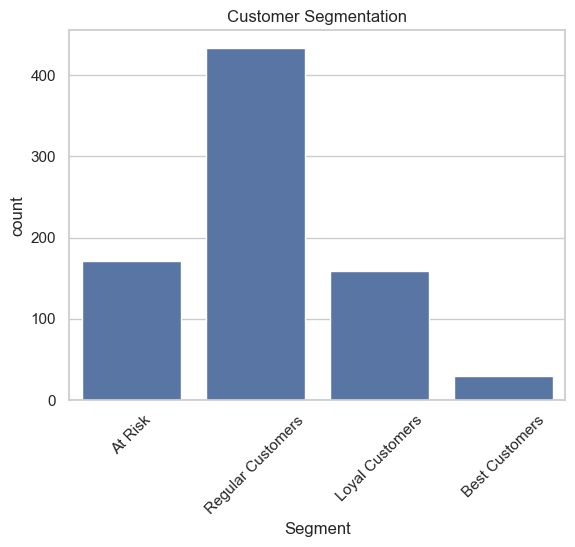

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Segment', data=rfm)
plt.xticks(rotation=45)
plt.title("Customer Segmentation")
plt.show()

Insights:

*A small group of customers contributes most revenue
*Some customers are at risk of churning
*Loyal customers should be retained